In [1]:
import pandas as pd
df = pd.read_csv('winequality-white.csv',sep=';')


In [2]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
print(df.head())
print(df.describe())
print(df.info())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5        6  
2     10.1        6 

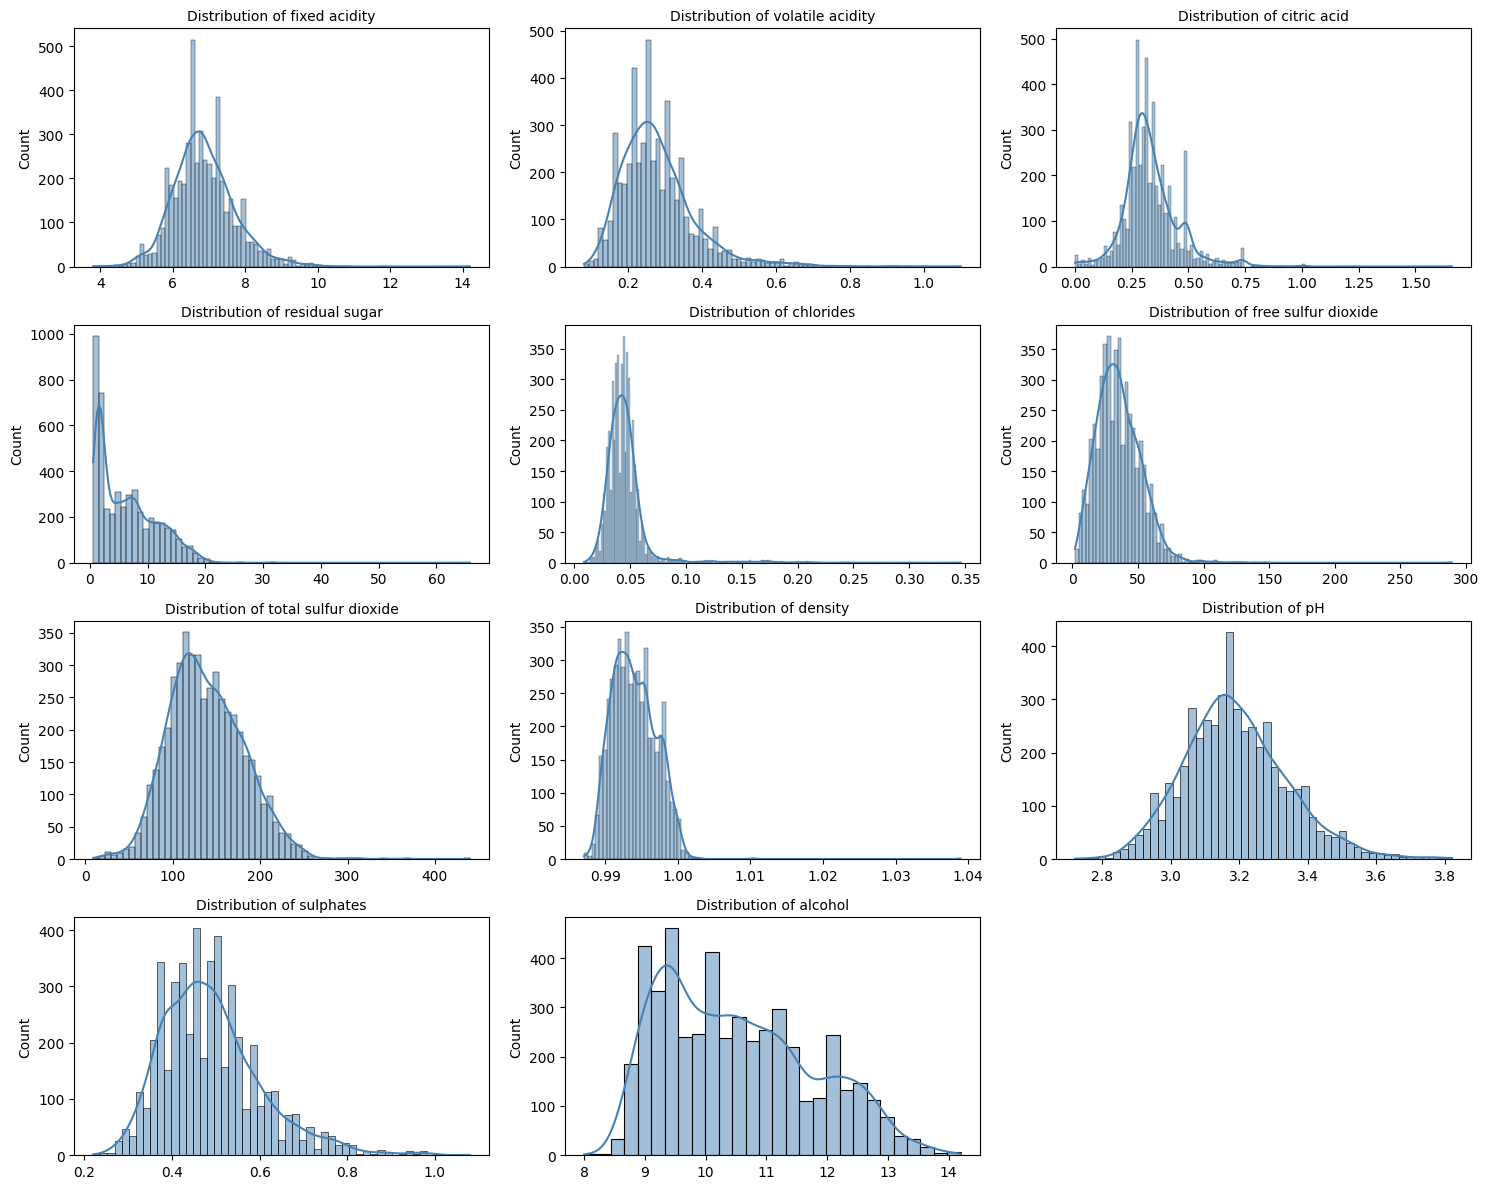

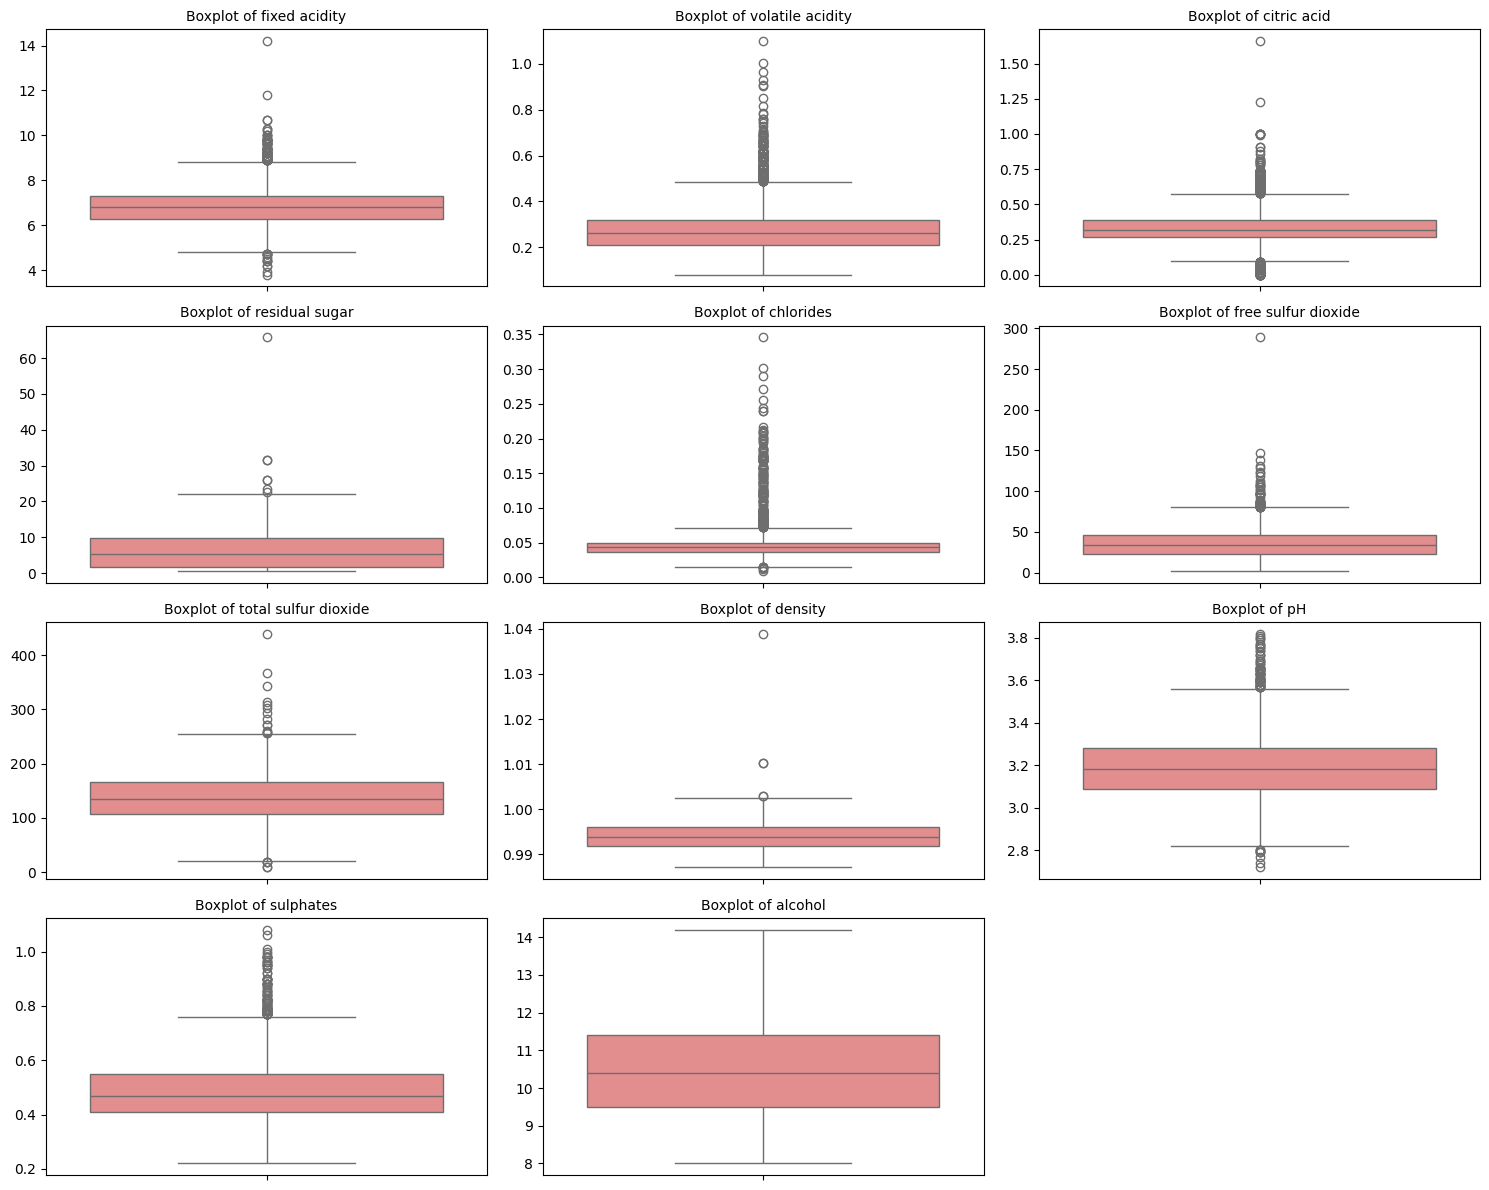

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
#Visualize distributions of key features using histograms or boxplots.
plt.figure(figsize=(15, 12))
for idx, feature in enumerate(df.columns[:-1], 1):
    plt.subplot(4, 3, idx)
    sns.histplot(df[feature], kde=True, color='steelblue')
    plt.title(f'Distribution of {feature}', fontsize=10)
    plt.xlabel('')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 12))
for idx, feature in enumerate(df.columns[:-1], 1):
    plt.subplot(4, 3, idx)
    sns.boxplot(y=df[feature], color='lightcoral')
    plt.title(f'Boxplot of {feature}', fontsize=10)
    plt.ylabel('')
plt.tight_layout()
plt.show()



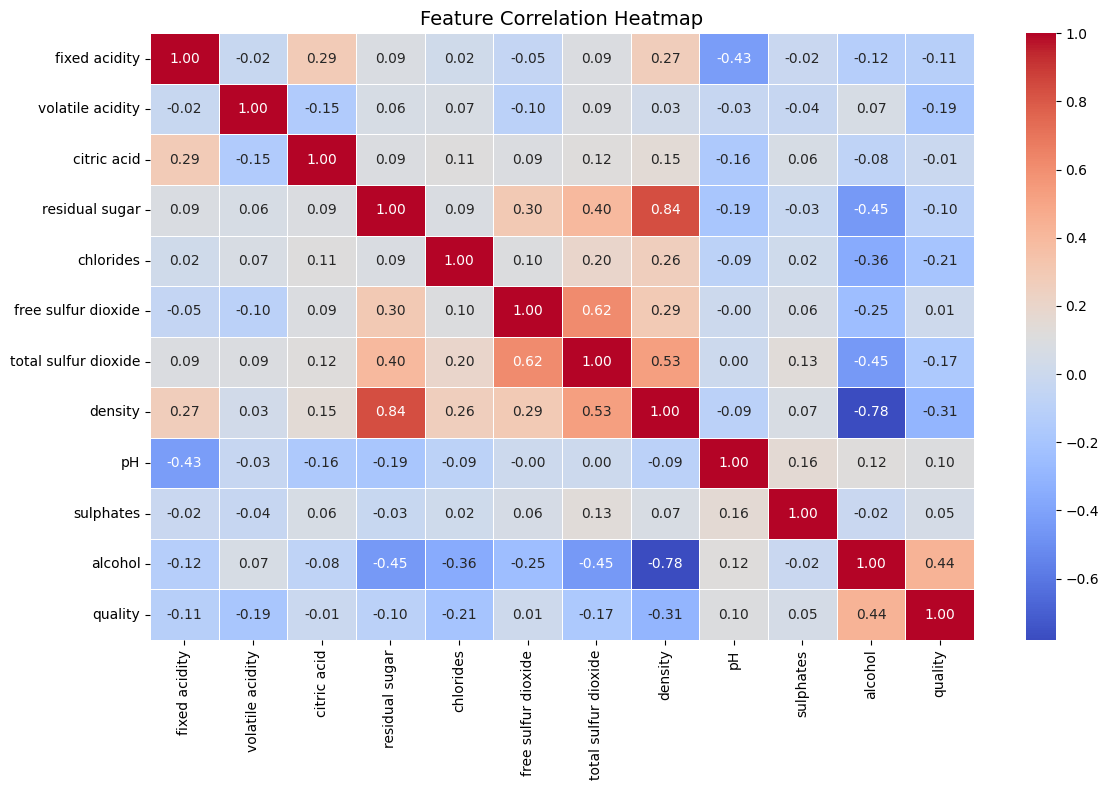

In [5]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
missing_values = df.isnull().sum()
display(missing_values)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [7]:
from sklearn.preprocessing import OneHotEncoder
cat_features = df.select_dtypes(include=['object']).columns
cat_features

Index([], dtype='object')

In [8]:

from sklearn.model_selection import train_test_split
X = df.drop('quality', axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
from sklearn.discriminant_analysis import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression
lr_base = LogisticRegression(
    multi_class='ovr',  
    random_state=42 
)
lr_base.fit(X_train_scaled, y_train)
lr_base_pred = lr_base.predict(X_test_scaled)

C:\Users\hetia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [11]:
from sklearn.neural_network import MLPClassifier
nn_base = MLPClassifier(
    hidden_layer_sizes=(64,), 
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    random_state=42
)
nn_base.fit(X_train_scaled, y_train)
nn_base_pred = nn_base.predict(X_test_scaled)

C:\Users\hetia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [12]:

from sklearn.metrics import classification_report
print(classification_report(y_test, lr_base_pred, zero_division=0))
print(classification_report(y_test, nn_base_pred, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        33
           5       0.58      0.51      0.54       291
           6       0.51      0.78      0.62       440
           7       0.46      0.15      0.22       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.53       980
   macro avg       0.22      0.20      0.20       980
weighted avg       0.49      0.53      0.48       980

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.42      0.15      0.22        33
           5       0.55      0.53      0.54       291
           6       0.53      0.66      0.59       440
           7       0.49      0.38      0.43       176
           8       0.40      0.06      0.10        35
           9       0.00 

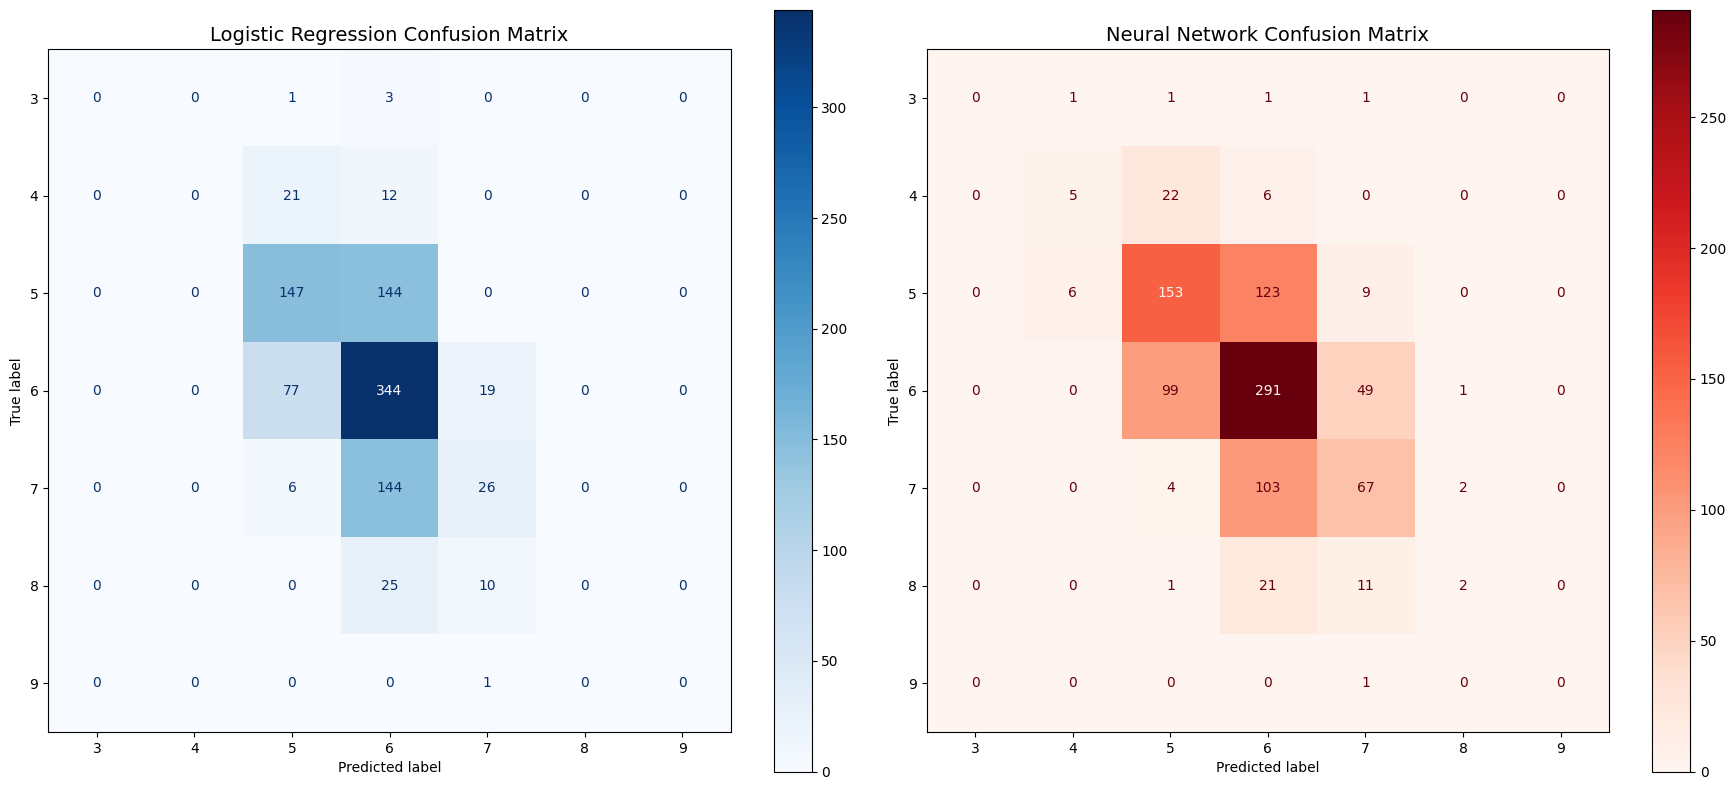

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
lr_cm = confusion_matrix(y_test, lr_base_pred)
ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=lr_base.classes_
).plot(ax=ax1, cmap='Blues')
ax1.set_title('Logistic Regression Confusion Matrix', fontsize=14)

nn_cm = confusion_matrix(y_test, nn_base_pred)
ConfusionMatrixDisplay(
    confusion_matrix=nn_cm,
    display_labels=nn_base.classes_
).plot(ax=ax2, cmap='Reds')
ax2.set_title('Neural Network Confusion Matrix', fontsize=14)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import GridSearchCV
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],             
    'multi_class': ['ovr'],
    'solver': ['liblinear'],
    'max_iter': [100,1000,2000],
    'random_state': [42]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train_scaled, y_train)

lr_best = lr_grid.best_estimator_
lr_best_pred = lr_best.predict(X_test_scaled)
print(classification_report(y_test, lr_best_pred, zero_division=0))

Fitting 5 folds for each of 36 candidates, totalling 180 fits


C:\Users\hetia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        33
           5       0.58      0.50      0.54       291
           6       0.51      0.78      0.62       440
           7       0.47      0.15      0.23       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.53       980
   macro avg       0.22      0.20      0.20       980
weighted avg       0.49      0.53      0.48       980



C:\Users\hetia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\hetia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


In [15]:
nn_param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (128,), (64, 32)], 
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [100, 1000, 2000],
    'solver': ['adam'],
    'random_state': [42]
}

nn_grid = GridSearchCV(
    estimator=MLPClassifier(),
    param_grid=nn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
nn_grid.fit(X_train_scaled, y_train)

nn_best = nn_grid.best_estimator_
nn_best_pred = nn_best.predict(X_test_scaled)
print(classification_report(y_test, nn_best_pred, zero_division=0))

C:\Users\hetia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Fitting 5 folds for each of 72 candidates, totalling 360 fits
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.29      0.24      0.26        33
           5       0.65      0.66      0.65       291
           6       0.65      0.65      0.65       440
           7       0.55      0.54      0.54       176
           8       0.48      0.60      0.53        35
           9       0.00      0.00      0.00         1

    accuracy                           0.61       980
   macro avg       0.37      0.38      0.38       980
weighted avg       0.61      0.61      0.61       980



C:\Users\hetia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model Name,Accuracy,Precision,Recall,F1-Score
0,Original Logistic Regression,0.5276,0.4864,0.5276,0.4788
1,Tuned Logistic Regression,0.5276,0.4874,0.5276,0.4785
2,Original Neural Network,0.5286,0.5175,0.5286,0.5121
3,Tuned Neural Network,0.6143,0.6111,0.6143,0.6123


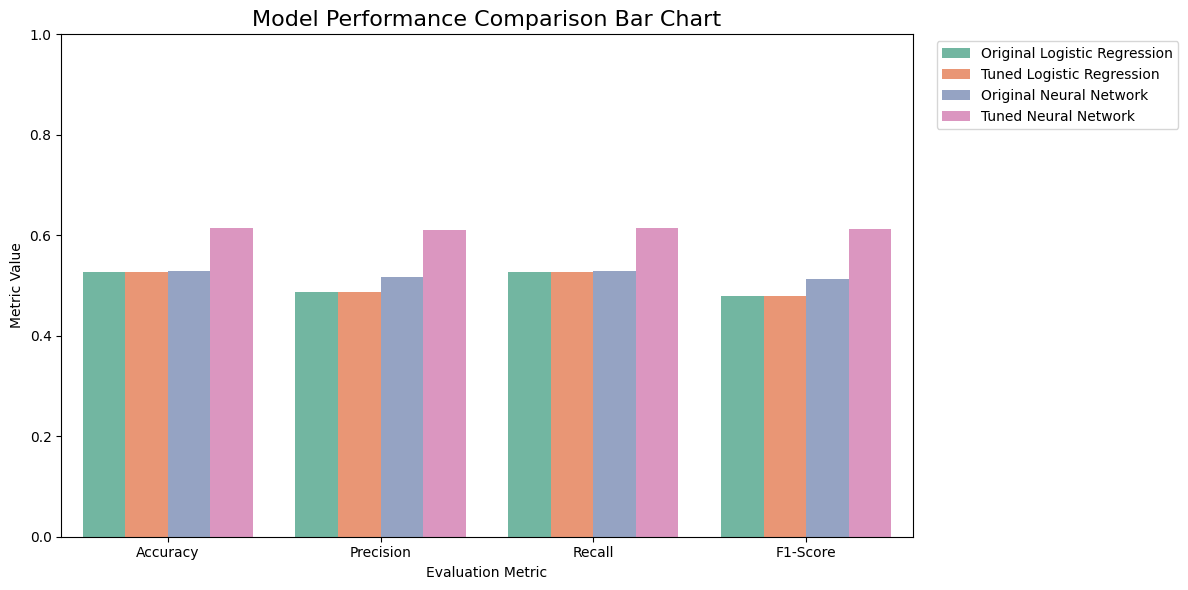

In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score,accuracy_score
def calculate_metrics(y_true, y_pred, model_name):
    return {
        'Model Name': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4)
    }

metrics_data = [
    calculate_metrics(y_test, lr_base_pred, 'Original Logistic Regression'),
    calculate_metrics(y_test, lr_best_pred, 'Tuned Logistic Regression'),
    calculate_metrics(y_test, nn_base_pred, 'Original Neural Network'),
    calculate_metrics(y_test, nn_best_pred, 'Tuned Neural Network')
]

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

plt.figure(figsize=(12, 6))
metrics_melted = metrics_df.melt(id_vars='Model Name', var_name='Evaluation Metric', value_name='Metric Value')
sns.barplot(x='Evaluation Metric', y='Metric Value', hue='Model Name', data=metrics_melted, palette='Set2')
plt.title('Model Performance Comparison Bar Chart', fontsize=16)
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [17]:
print("Best Logistic Regression Parameters:", lr_grid.best_params_)
print("Best Neural Network Parameters:", nn_grid.best_params_)

Best Logistic Regression Parameters: {'C': 1, 'max_iter': 100, 'multi_class': 'ovr', 'penalty': 'l1', 'random_state': 42, 'solver': 'liblinear'}
Best Neural Network Parameters: {'activation': 'tanh', 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'max_iter': 1000, 'random_state': 42, 'solver': 'adam'}
